In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
import joblib

In [27]:
df = pd.read_csv("emails.csv")
df.head(3)

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1


In [28]:
print(df.shape)
print(df.info())
print(df.isnull().sum())
print(df['spam'].value_counts())

(5728, 2)
<class 'pandas.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    5728 non-null   str  
 1   spam    5728 non-null   int64
dtypes: int64(1), str(1)
memory usage: 89.6 KB
None
text    0
spam    0
dtype: int64
spam
0    4360
1    1368
Name: count, dtype: int64


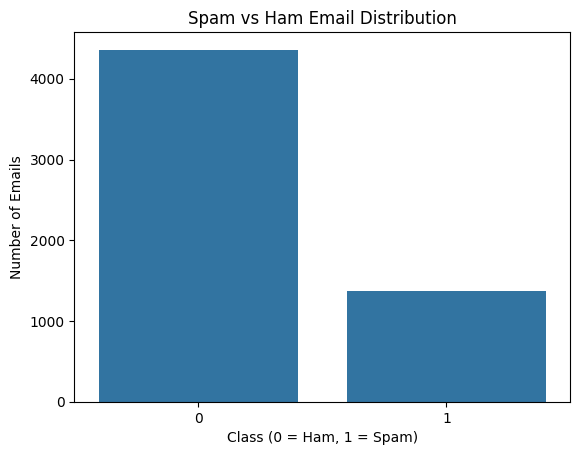

In [29]:
sns.countplot(x='spam', data=df)
plt.title("Spam vs Ham Email Distribution")
plt.xlabel("Class (0 = Ham, 1 = Spam)")
plt.ylabel("Number of Emails")
plt.show()

In [30]:
synthetic_df = pd.read_csv("synthetic_spam_combined.csv")

In [31]:
final_df = pd.concat([df, synthetic_df], ignore_index=True)

In [32]:
final_df = final_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [33]:
final_df.to_csv("balanced_spam_dataset.csv", index=False)

In [34]:
print(final_df["spam"].value_counts())

spam
0    4360
1    3875
Name: count, dtype: int64


In [35]:
print(final_df.shape)
print("\nMissing values:")
print(final_df.isnull().sum())
print("\nDuplicate emails:")
print(final_df.duplicated(subset=["text"]).sum())
print("\nClass distribution:")
print(final_df["spam"].value_counts())

(8235, 2)

Missing values:
text    0
spam    0
dtype: int64

Duplicate emails:
33

Class distribution:
spam
0    4360
1    3875
Name: count, dtype: int64


In [36]:
final_df = final_df.drop_duplicates(subset=["text"]).reset_index(drop=True)

print("Remaining duplicates:", final_df.duplicated(subset=["text"]).sum())
print(final_df["spam"].value_counts())

Remaining duplicates: 0
spam
0    4327
1    3875
Name: count, dtype: int64


In [37]:
final_df.to_csv("balanced_spam_dataset.csv", index=False)

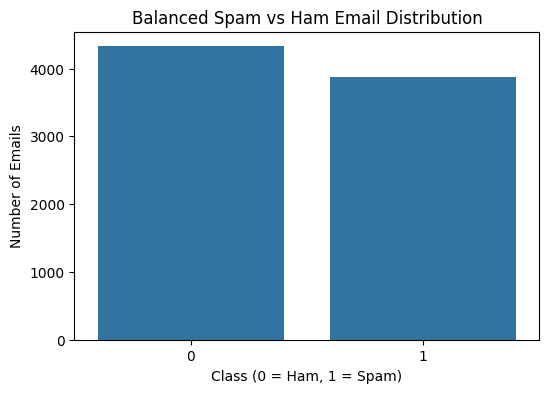

In [38]:
plt.figure(figsize=(6,4))
sns.countplot(x='spam', data=final_df)
plt.title("Balanced Spam vs Ham Email Distribution")
plt.xlabel("Class (0 = Ham, 1 = Spam)")
plt.ylabel("Number of Emails")
plt.show()

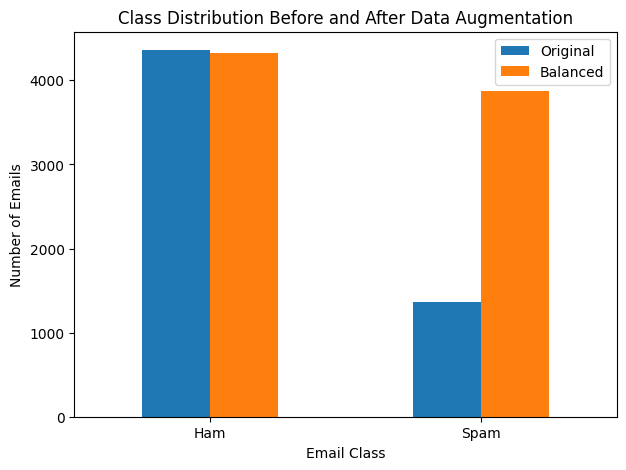

In [40]:
comparison = pd.DataFrame({
    "Original": df['spam'].value_counts().sort_index(),
    "Balanced": final_df['spam'].value_counts().sort_index()
})
comparison.index = ["Ham", "Spam"]
comparison.plot(kind="bar", figsize=(7,5))
plt.title("Class Distribution Before and After Data Augmentation")
plt.xlabel("Email Class")
plt.ylabel("Number of Emails")
plt.xticks(rotation=0)
plt.show()

In [41]:
real_df = df.copy()
print(real_df["spam"].value_counts())
X_real = real_df["text"]
y_real = real_df["spam"]

spam
0    4360
1    1368
Name: count, dtype: int64


In [42]:
X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(
    X_real,
    y_real,
    test_size=0.2,
    random_state=42,
    stratify=y_real
)
print("Training samples:", len(X_train_real))
print("Testing samples:", len(X_test_real))

Training samples: 4582
Testing samples: 1146


In [43]:
tfidf_real = TfidfVectorizer(
    lowercase=True,
    stop_words="english"
)
X_train_real_tfidf = tfidf_real.fit_transform(X_train_real)
X_test_real_tfidf = tfidf_real.transform(X_test_real)

In [18]:
#lowercase = True
#FREE

#Free

#free
#stop_words="english"
#the

#is

#of

#and

#for
#fit()
#Win money

#Free money

#Meeting today
#this becomes 
#Win

#Free

#Money

#Meeting

#Today
#transform()
#Win money  [0.71 0 0.71 0 0]

In [44]:
rf_real = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf_real.fit(
    X_train_real_tfidf,
    y_train_real
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [45]:
y_pred_real = rf_real.predict(X_test_real_tfidf)
real_accuracy = accuracy_score(y_test_real,y_pred_real)
real_precision = precision_score(y_test_real,y_pred_real)
real_recall = recall_score(y_test_real,y_pred_real)
real_f1 = f1_score(y_test_real,y_pred_real)
print("REAL DATA PERFORMANCE")
print("---------------------")
print("Accuracy :",real_accuracy)
print("Precision:",real_precision)
print("Recall   :",real_recall)
print("F1 Score :",real_f1)
print(classification_report(
    y_test_real,
    y_pred_real
))

REAL DATA PERFORMANCE
---------------------
Accuracy : 0.9860383944153578
Precision: 0.9886363636363636
Recall   : 0.9525547445255474
F1 Score : 0.9702602230483272
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       872
           1       0.99      0.95      0.97       274

    accuracy                           0.99      1146
   macro avg       0.99      0.97      0.98      1146
weighted avg       0.99      0.99      0.99      1146



In [46]:
augmented_df = final_df.copy()
print(augmented_df["spam"].value_counts())
X_aug = augmented_df["text"]
y_aug = augmented_df["spam"]

spam
0    4327
1    3875
Name: count, dtype: int64


In [47]:
X_train_aug, X_test_aug, y_train_aug, y_test_aug = train_test_split(
    X_aug,
    y_aug,
    test_size=0.2,
    random_state=42,
    stratify=y_aug
)
print("Training samples:",len(X_train_aug))
print("Testing samples:",len(X_test_aug))

Training samples: 6561
Testing samples: 1641


In [48]:
tfidf_aug = TfidfVectorizer(
    lowercase=True,
    stop_words="english"
)
X_train_aug_tfidf = tfidf_aug.fit_transform(
    X_train_aug
)
X_test_aug_tfidf = tfidf_aug.transform(
    X_test_aug
)

In [49]:
rf_aug = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf_aug.fit(
    X_train_aug_tfidf,
    y_train_aug
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [50]:
y_pred_aug = rf_aug.predict(X_test_aug_tfidf)
aug_accuracy = accuracy_score(y_test_aug,y_pred_aug)
aug_precision = precision_score(y_test_aug,y_pred_aug)
aug_recall = recall_score(y_test_aug,y_pred_aug)
aug_f1 = f1_score(y_test_aug,y_pred_aug)
print("REAL + SYNTHETIC PERFORMANCE")
print("-----------------------------")
print("Accuracy :",aug_accuracy)
print("Precision:",aug_precision)
print("Recall   :",aug_recall)
print("F1 Score :",aug_f1)
print(classification_report(
    y_test_aug,
    y_pred_aug
))

REAL + SYNTHETIC PERFORMANCE
-----------------------------
Accuracy : 0.9890310786106032
Precision: 0.9973718791064389
Recall   : 0.9793548387096774
F1 Score : 0.98828125
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       866
           1       1.00      0.98      0.99       775

    accuracy                           0.99      1641
   macro avg       0.99      0.99      0.99      1641
weighted avg       0.99      0.99      0.99      1641



In [51]:
results = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Real Only":[
        real_accuracy,
        real_precision,
        real_recall,
        real_f1
    ],
    "Real + Synthetic":[
        aug_accuracy,
        aug_precision,
        aug_recall,
        aug_f1
    ]
})
results

,Metric,Real Only,Real + Synthetic
0,Accuracy,0.986038,0.989031
1,Precision,0.988636,0.997372
2,Recall,0.952555,0.979355
3,F1 Score,0.970260,0.988281


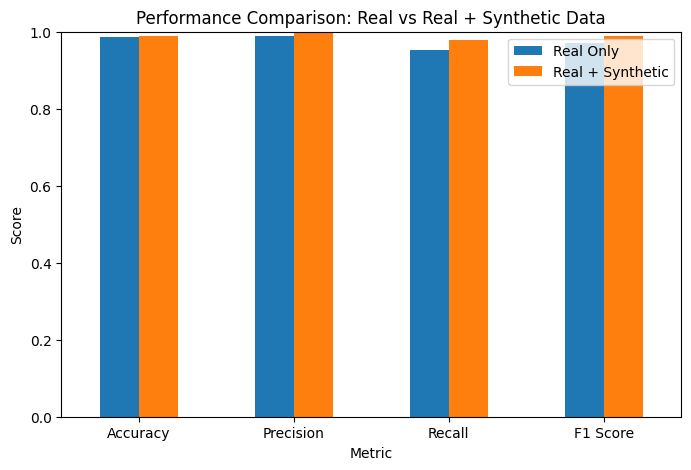

In [52]:
results.set_index("Metric").plot(
    kind="bar",
    figsize=(8,5)
)
plt.title(
    "Performance Comparison: Real vs Real + Synthetic Data"
)
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.show()

In [53]:
real_text = df["text"]
synthetic_text = synthetic_df["text"]
combined_text = pd.concat(
    [
        real_text,
        synthetic_text
    ],
    ignore_index=True
)
labels = (
    ["Real"] * len(real_text)
    +
    ["Synthetic"] * len(synthetic_text)
)

In [54]:
tfidf_vis = TfidfVectorizer(
    max_features=500
)
X_vis = tfidf_vis.fit_transform(
    combined_text
)

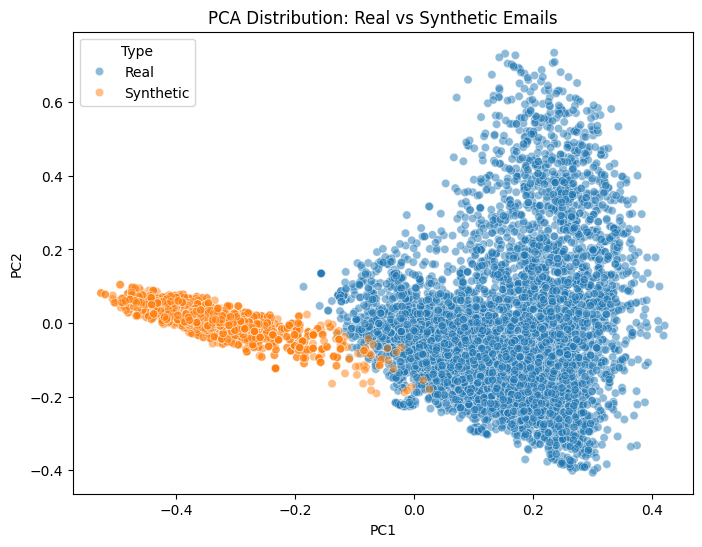

In [55]:
pca = PCA(
    n_components=2
)
X_pca = pca.fit_transform(
    X_vis.toarray()
)
pca_df = pd.DataFrame({

    "PC1":X_pca[:,0],
    "PC2":X_pca[:,1],
    "Type":labels

})
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Type",
    alpha=0.5
)
plt.title(
    "PCA Distribution: Real vs Synthetic Emails"
)
plt.show()

In [56]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Explained Variance:", pca.explained_variance_ratio_.sum())

Explained Variance Ratio: [0.07232061 0.03450036]
Total Explained Variance: 0.10682096762744661


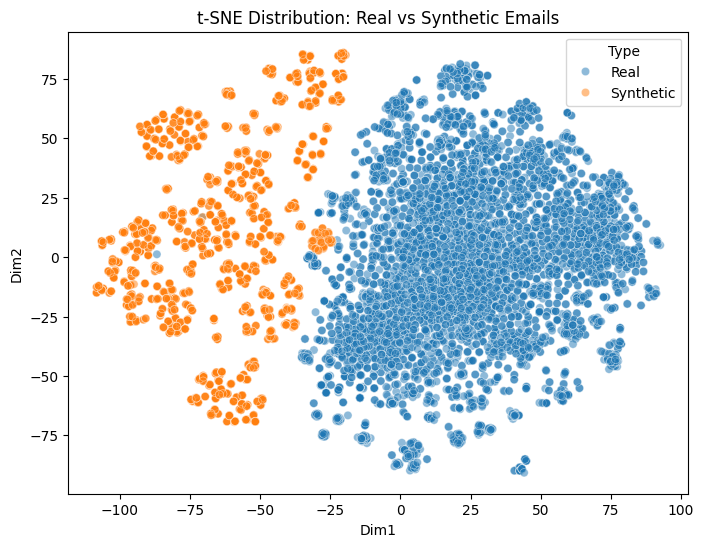

In [57]:
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)
X_tsne = tsne.fit_transform(
    X_vis.toarray()
)
tsne_df = pd.DataFrame({

    "Dim1":X_tsne[:,0],
    "Dim2":X_tsne[:,1],
    "Type":labels

})
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=tsne_df,
    x="Dim1",
    y="Dim2",
    hue="Type",
    alpha=0.5
)
plt.title(
    "t-SNE Distribution: Real vs Synthetic Emails"
)
plt.show()

In [58]:
import joblib

joblib.dump(rf_aug, "random_forest_model.pkl")
joblib.dump(tfidf_aug, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']